In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

`make_moons` is a classic synthetic dataset: two classes that draw interlocking half-moons. **No straight line** can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

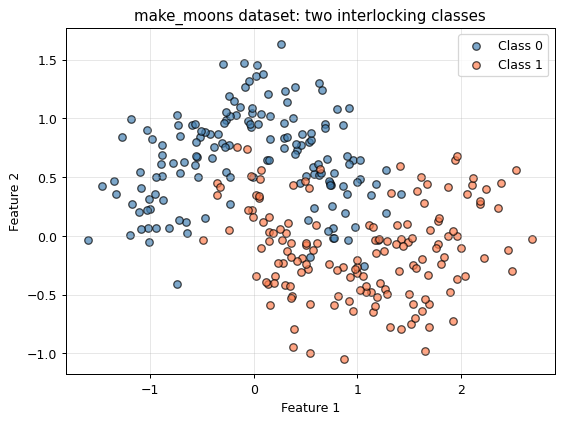

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Mejores parámetros : {'clf__C': 100, 'clf__penalty': 'l1', 'clf__solver': 'saga', 'poly__degree': 3}
CV accuracy (train): 0.9208
Accuracy (test)    : 0.9167

              precision    recall  f1-score   support

           0       0.96      0.85      0.90        26
           1       0.89      0.97      0.93        34

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60



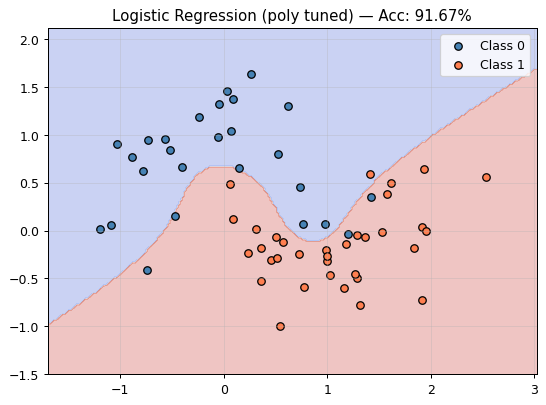

In [5]:
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=10000))
])

param_grid = {
    'poly__degree': [2, 3, 4],
    'clf__C':       [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear', 'saga']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
acc_logreg  = accuracy_score(y_test, best_model.predict(X_test))
cv_score    = grid.best_score_

print(f'Mejores parámetros : {grid.best_params_}')
print(f'CV accuracy (train): {cv_score:.4f}')
print(f'Accuracy (test)    : {acc_logreg:.4f}')
print()
print(classification_report(y_test, best_model.predict(X_test)))

plot_decision_boundary(best_model, X_test, y_test,
                       f'Logistic Regression (poly tuned) — Acc: {acc_logreg:.2%}')

Accuracy (test): 0.8833

              precision    recall  f1-score   support

           0       0.91      0.81      0.86        26
           1       0.86      0.94      0.90        34

    accuracy                           0.88        60
   macro avg       0.89      0.87      0.88        60
weighted avg       0.89      0.88      0.88        60



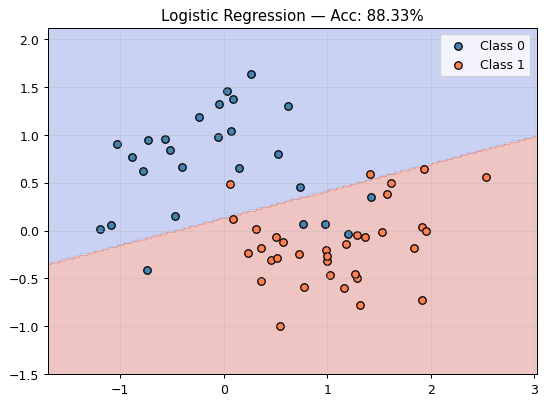

In [10]:
# ===== Regresión Logística (pura, sin polinomios) =====

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=10000))
])

pipe.fit(X_train, y_train)

y_pred     = pipe.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred)

print(f'Accuracy (test): {acc_logreg:.4f}')
print()
print(classification_report(y_test, y_pred))

plot_decision_boundary(pipe, X_test, y_test,
                       f'Logistic Regression — Acc: {acc_logreg:.2%}')

## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it **learns questions**:

```
Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1
```

Each question splits the space with a **line parallel to one axis**. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

RandomForest: 0.933
GradientBoosting: 0.900
SVM-RBF: 0.933
KNN: 0.967

Mejor modelo: KNN — Acc: 96.67%
Mejora vs logistic regression: +8.3 puntos


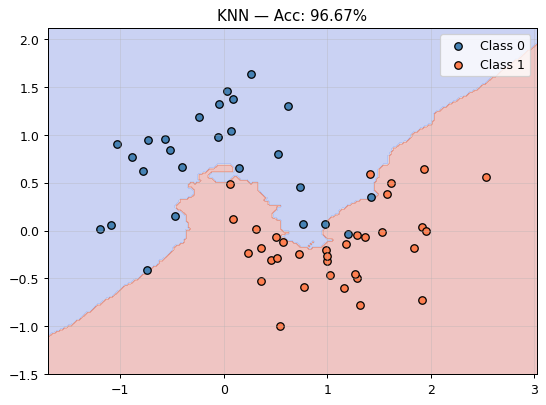

In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

modelos = {
    'RandomForest':     RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    'SVM-RBF':          make_pipeline(StandardScaler(), SVC(C=10, gamma='scale', random_state=42)),
    'KNN':              make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
}

resultados = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    resultados[nombre] = (acc, m)
    print(f'{nombre}: {acc:.3f}')

# elige el mejor automáticamente
mejor = max(resultados, key=lambda k: resultados[k][0])
acc_mejor, modelo_mejor = resultados[mejor]

print(f'\nMejor modelo: {mejor} — Acc: {acc_mejor:.2%}')
print(f'Mejora vs logistic regression: +{(acc_mejor - acc_logreg)*100:.1f} puntos')

plot_decision_boundary(modelo_mejor, X_test, y_test, f'{mejor} — Acc: {acc_mejor:.2%}')